# Ejercicio de Feedback 1

**Asignatura:** Calibración, Métricas y Explicabilidad de Modelos de IA
**Universidad:** UAX - Universidad Alfonso X El Sabio
**Dataset:** Repositorio por Defecto Tarjetas de Clientes

In [249]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import shap
import warnings
import os
import tqdm as notebook_tqdm
from imblearn.over_sampling import SMOTE
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.validation import check_is_fitted
import joblib
shap.initjs()
warnings.filterwarnings('ignore')

## Limpieza

In [16]:
dataset = pd.read_excel('../data/taiwan-credit-cards.xls', index_col=0, header=1)
df_banco = dataset.copy()
df_banco.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [17]:
print("Columnas:", list(df_banco.columns))
df_banco.describe()

Columnas: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [18]:
df_banco.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_AMT4        

In [19]:
df_banco.duplicated().sum()

np.int64(35)

In [20]:
df_banco.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [21]:
import json

path = '../data/dictionary.json'
dicitionary = ''
with open(path, 'r') as file:
    dictionary = json.load(file)
print(dictionary)

{'LIMIT_BAL': 'limite_credito', 'SEX': 'genero', 'EDUCATION': 'nivel_educativo', 'MARRIAGE': 'estado_civil', 'AGE': 'edad', 'PAY_0': 'est_pago_sep', 'PAY_2': 'est_pago_ago', 'PAY_3': 'est_pago_jul', 'PAY_4': 'est_pago_jun', 'PAY_5': 'est_pago_may', 'PAY_6': 'est_pago_abr', 'BILL_AMT1': 'deuda_sep', 'BILL_AMT2': 'deuda_ago', 'BILL_AMT3': 'deuda_jul', 'BILL_AMT4': 'deuda_jun', 'BILL_AMT5': 'deuda_may', 'BILL_AMT6': 'deuda_abr', 'PAY_AMT1': 'pago_sep', 'PAY_AMT2': 'pago_ago', 'PAY_AMT3': 'pago_jul', 'PAY_AMT4': 'pago_jun', 'PAY_AMT5': 'pago_may', 'PAY_AMT6': 'pago_abr', 'default payment next month': 'incumplimiento_sig_mes'}


In [22]:
# Aplicar el renombramiento
df_banco = df_banco.rename(columns=dictionary)

# Verificar
print(df_banco.columns)

Index(['limite_credito', 'genero', 'nivel_educativo', 'estado_civil', 'edad',
       'est_pago_sep', 'est_pago_ago', 'est_pago_jul', 'est_pago_jun',
       'est_pago_may', 'est_pago_abr', 'deuda_sep', 'deuda_ago', 'deuda_jul',
       'deuda_jun', 'deuda_may', 'deuda_abr', 'pago_sep', 'pago_ago',
       'pago_jul', 'pago_jun', 'pago_may', 'pago_abr',
       'incumplimiento_sig_mes'],
      dtype='str')


In [23]:
df_banco.isnull().sum()

limite_credito            0
genero                    0
nivel_educativo           0
estado_civil              0
edad                      0
est_pago_sep              0
est_pago_ago              0
est_pago_jul              0
est_pago_jun              0
est_pago_may              0
est_pago_abr              0
deuda_sep                 0
deuda_ago                 0
deuda_jul                 0
deuda_jun                 0
deuda_may                 0
deuda_abr                 0
pago_sep                  0
pago_ago                  0
pago_jul                  0
pago_jun                  0
pago_may                  0
pago_abr                  0
incumplimiento_sig_mes    0
dtype: int64

In [24]:
df_banco.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   limite_credito          30000 non-null  int64
 1   genero                  30000 non-null  int64
 2   nivel_educativo         30000 non-null  int64
 3   estado_civil            30000 non-null  int64
 4   edad                    30000 non-null  int64
 5   est_pago_sep            30000 non-null  int64
 6   est_pago_ago            30000 non-null  int64
 7   est_pago_jul            30000 non-null  int64
 8   est_pago_jun            30000 non-null  int64
 9   est_pago_may            30000 non-null  int64
 10  est_pago_abr            30000 non-null  int64
 11  deuda_sep               30000 non-null  int64
 12  deuda_ago               30000 non-null  int64
 13  deuda_jul               30000 non-null  int64
 14  deuda_jun               30000 non-null  int64
 15  deuda_may               30000 

## Analisis Exploratorio de los Datos (EDA)

In [25]:
# samuel
def feature_engineering(df_banco):
    df_new = df_banco.copy()
   
    # Limpiar variables categoricas 
    df_new['genero'] = df_new['genero'].map({1: 1, 2: 0}) # 1: Hombre, 0: Mujer

    # Educación: Agrupar valores desconocidos (0, 5, 6) en 'Otros' (4)
    # 1: Posgrado, 2: Universidad, 3: Secundaria, 4: Otros
    df_new['nivel_educativo'] = df_new['nivel_educativo'].replace([0, 5, 6], 4) 
    

    # Estado Civil: Agrupar 0 en 3 (Otros)
    # 1: Casado, 2: Soltero, 3: Otros 
    df_new['estado_civil'] = df_new['estado_civil'].replace({0: 3})
    
    bill_cols = ['deuda_sep', 'deuda_ago', 'deuda_jul', 'deuda_jun', 'deuda_may', 'deuda_abr']
    for col in bill_cols:
      new_col_name = col.replace('deuda_', 'util_')
      df_new[new_col_name] = df_new[col] / df_new['limite_credito']

    # Promedio de estado de pago (PAY_X)
    # Captura el comportamiento de retraso histórico
    pay_cols = ['est_pago_sep', 'est_pago_ago', 'est_pago_jul', 'est_pago_jun', 'est_pago_may', 'est_pago_abr']
    df_new['avg_retraso'] = df_new[pay_cols].mean(axis=1)

    # ¿La deuda esta subiendo o bajando? (Septiembre vs Agosto)
    df_new['var_deuda_reciente'] = df_new['deuda_sep'] - df_new['deuda_ago']

    # El pago de septiembre corresponde a la deuda generada en agosto
    # ¿Que porcentaje de la deuda anterior pagó el cliente?
    # El pago de septiembre corresponde a la deuda generado en agosto
    df_new['ratio_pago_sep'] = np.where(df_new['deuda_ago'] > 0, df_new['pago_sep'] / df_new['deuda_ago'], 0)

    # Total de pagos y deudas
    df_new['total_pagos'] = df_new[['pago_sep', 'pago_ago', 'pago_jul', 'pago_jun', 'pago_may', 'pago_abr']].sum(axis=1)
    df_new['total_deuda'] = df_new[bill_cols].sum(axis=1)

    return df_new

df_banco_extended = feature_engineering(df_banco)

df_banco_extended[['limite_credito', 'util_sep', 'avg_retraso', 'ratio_pago_sep']].head(10)
   


,limite_credito,util_sep,avg_retraso,ratio_pago_sep
ID,,,,
1,20000,0.195650,-0.333333,0.000000
2,120000,0.022350,0.500000,0.000000
3,90000,0.324878,0.000000,0.108220
4,50000,0.939800,0.000000,0.041465
5,50000,0.172340,-0.333333,0.352734
6,50000,1.288000,0.000000,0.043807
7,500000,0.735930,0.000000,0.133488
8,100000,0.118760,-0.500000,1.000000
9,140000,0.080607,0.333333,0.236166


In [26]:
def feature_engineering_bins(df_banco):
    df_banco['rango_edad'] = pd.cut(x = df_banco['edad'], 
                                   bins=[18, 30, 40, 50, 60, 70, 80], 
                                   labels = [1, 2, 3, 4, 5, 6])

    cortes_credito = [0, 50000, 100000, 200000, 300000, 400000, 500000, 1100000]
    etiquetas_credito = [1, 2, 3, 4, 5, 6, 7]
    
    df_banco['rango_valor_credito'] = pd.cut(x= df_banco['limite_credito'], 
                                             bins=cortes_credito, 
                                             labels=etiquetas_credito) 
    return df_banco

df_banco = feature_engineering_bins(df_banco)
df_banco

,limite_credito,genero,nivel_educativo,estado_civil,edad,est_pago_sep,est_pago_ago,est_pago_jul,est_pago_jun,est_pago_may,...,deuda_abr,pago_sep,pago_ago,pago_jul,pago_jun,pago_may,pago_abr,incumplimiento_sig_mes,rango_edad,rango_valor_credito
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,1,1,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,1,1,3
3,90000,2,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,2,2
4,50000,2,2,1,37,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,2,1
5,50000,1,2,1,57,-1,0,-1,0,0,...,19131,2000,36681,10000,9000,689,679,0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,220000,1,3,1,39,0,0,0,0,0,...,15980,8500,20000,5003,3047,5000,1000,0,2,4
29997,150000,1,3,2,43,-1,-1,-1,-1,0,...,0,1837,3526,8998,129,0,0,0,3,3
29998,30000,1,2,2,37,4,3,2,-1,0,...,19357,0,0,22000,4200,2000,3100,1,2,1


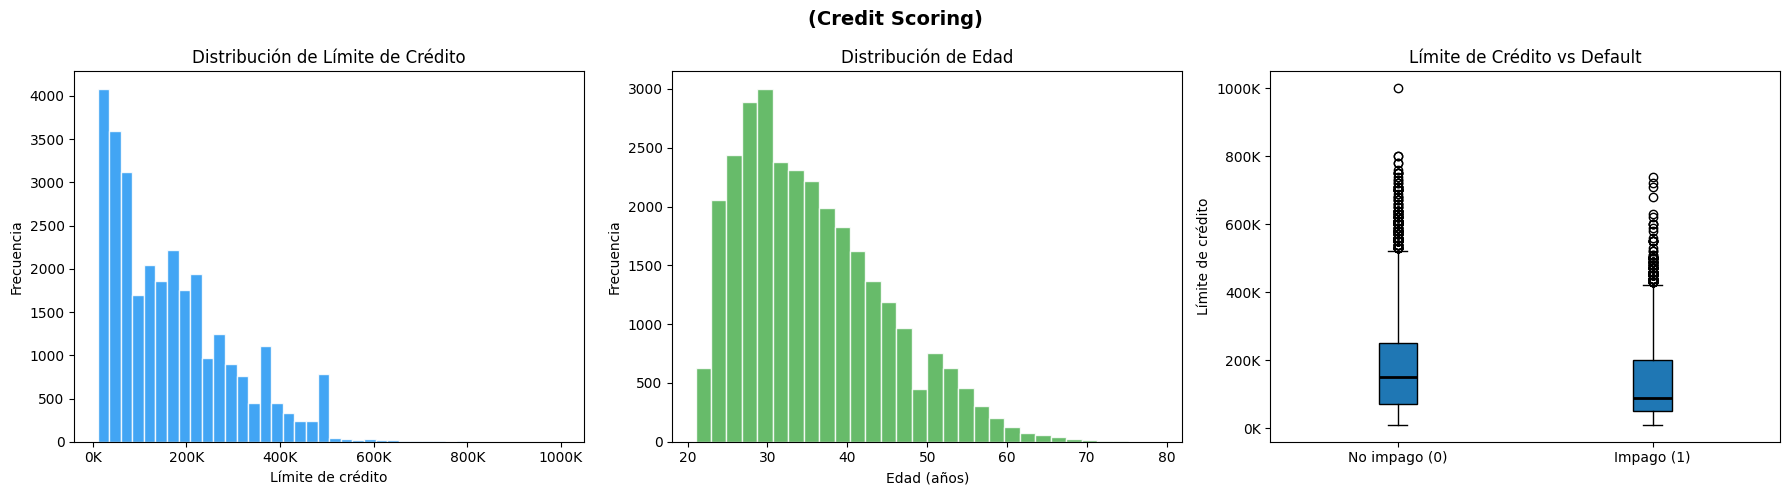

Estadísticos de Límite de Crédito por Target
                          count      mean       std      min      25%  \
incumplimiento_sig_mes                                                  
0                       23364.0  178100.0  131628.0  10000.0  70000.0   
1                        6636.0  130110.0  115379.0  10000.0  50000.0   

                             50%       75%        max  
incumplimiento_sig_mes                                 
0                       150000.0  250000.0  1000000.0  
1                        90000.0  200000.0   740000.0  

--- Estadísticos de Edad
count    30000.0
mean        35.5
std          9.2
min         21.0
25%         28.0
50%         34.0
75%         41.0
max         79.0
Name: edad, dtype: float64


In [27]:
def analisis_exploratorio_datos(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].hist(df['limite_credito'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
    axes[0].set_title('Distribución de Límite de Crédito')
    axes[0].set_xlabel('Límite de crédito')
    axes[0].set_ylabel('Frecuencia')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    
    axes[1].hist(df['edad'], bins=30, color='#4CAF50', edgecolor='white', alpha=0.85)
    axes[1].set_title('Distribución de Edad')
    axes[1].set_xlabel('Edad (años)')
    axes[1].set_ylabel('Frecuencia')

    data_0 = df[df['incumplimiento_sig_mes'] == 0]['limite_credito']
    data_1 = df[df['incumplimiento_sig_mes'] == 1]['limite_credito']
    
    axes[2].boxplot([data_0, data_1], 
                     labels=['No impago (0)', 'Impago (1)'],
                     patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})

    axes[2].set_title('Límite de Crédito vs Default')
    axes[2].set_ylabel('Límite de crédito')
    axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    
    plt.suptitle('(Credit Scoring)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Estadísticos de Límite de Crédito por Target")
    print(df.groupby('incumplimiento_sig_mes')['limite_credito'].describe().round(0))
    print("\n--- Estadísticos de Edad")
    print(df['edad'].describe().round(1))

analisis_exploratorio_datos(df_banco)

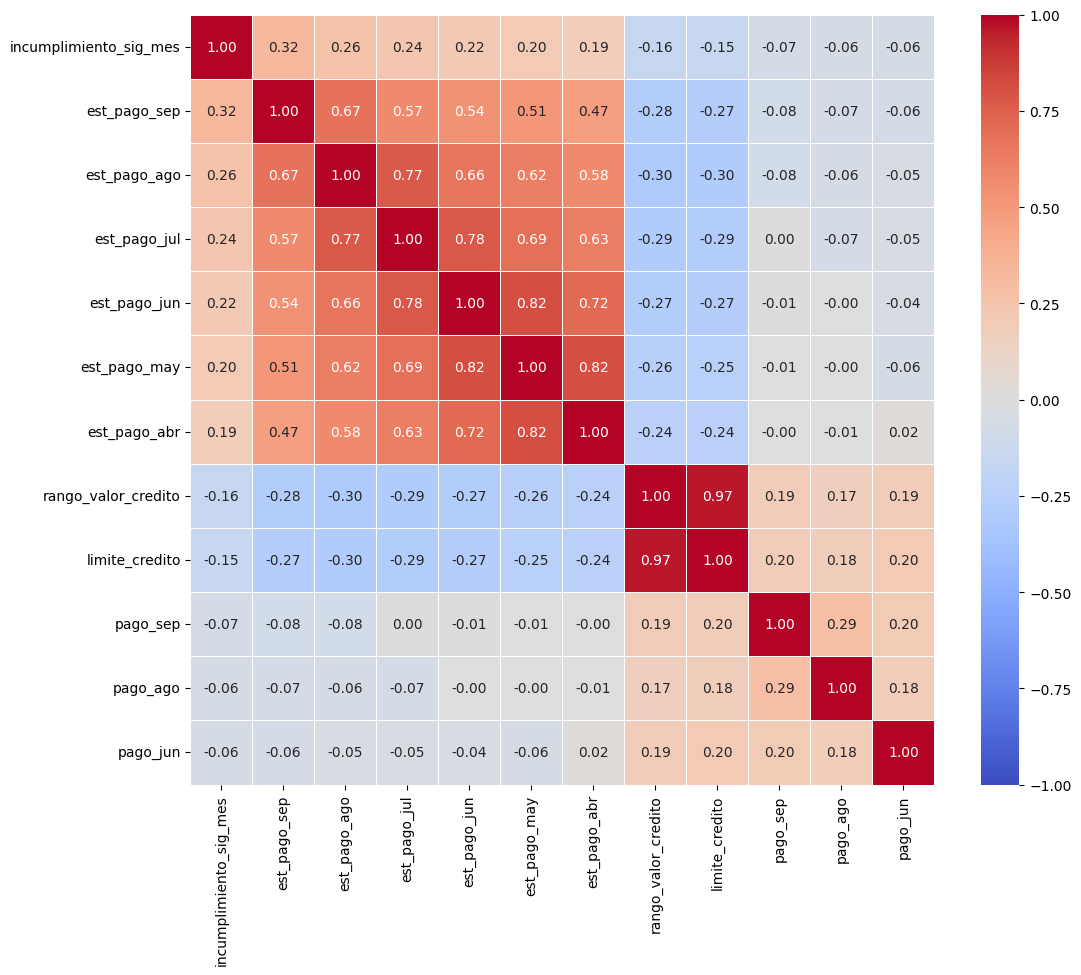

In [28]:
top_corr = df_banco.corr()['incumplimiento_sig_mes'].abs().sort_values(ascending=False)

indices_importantes = top_corr.index[:12] 
matriz_reducida = df_banco[indices_importantes].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_reducida, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            linewidths=0.5,
            vmin=-1, vmax=1)
plt.show()

In [29]:
df_banco.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   limite_credito          30000 non-null  int64   
 1   genero                  30000 non-null  int64   
 2   nivel_educativo         30000 non-null  int64   
 3   estado_civil            30000 non-null  int64   
 4   edad                    30000 non-null  int64   
 5   est_pago_sep            30000 non-null  int64   
 6   est_pago_ago            30000 non-null  int64   
 7   est_pago_jul            30000 non-null  int64   
 8   est_pago_jun            30000 non-null  int64   
 9   est_pago_may            30000 non-null  int64   
 10  est_pago_abr            30000 non-null  int64   
 11  deuda_sep               30000 non-null  int64   
 12  deuda_ago               30000 non-null  int64   
 13  deuda_jul               30000 non-null  int64   
 14  deuda_jun               30000 non

In [30]:
df_banco['incumplimiento_sig_mes'].value_counts()
df_banco_limpieza = df_banco
df_banco_limpieza.to_csv('df_banco_final.csv', sep=';', index=False)

# Entrenamiento y Evaluación de Modelos

In [60]:
clean_dataset = pd.read_csv('df_banco_final.csv', sep=';')
features = clean_dataset.drop(columns=['incumplimiento_sig_mes'])
target = clean_dataset['incumplimiento_sig_mes']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42, stratify=target)

In [61]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)  

In [64]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)
print("Dimensiones de X_train: ", X_train_res.shape)
print("Dimensiones de y_train_res: ", y_train_res.shape)

Dimensiones de X_train:  (32710, 25)
Dimensiones de y_train_res:  (32710,)


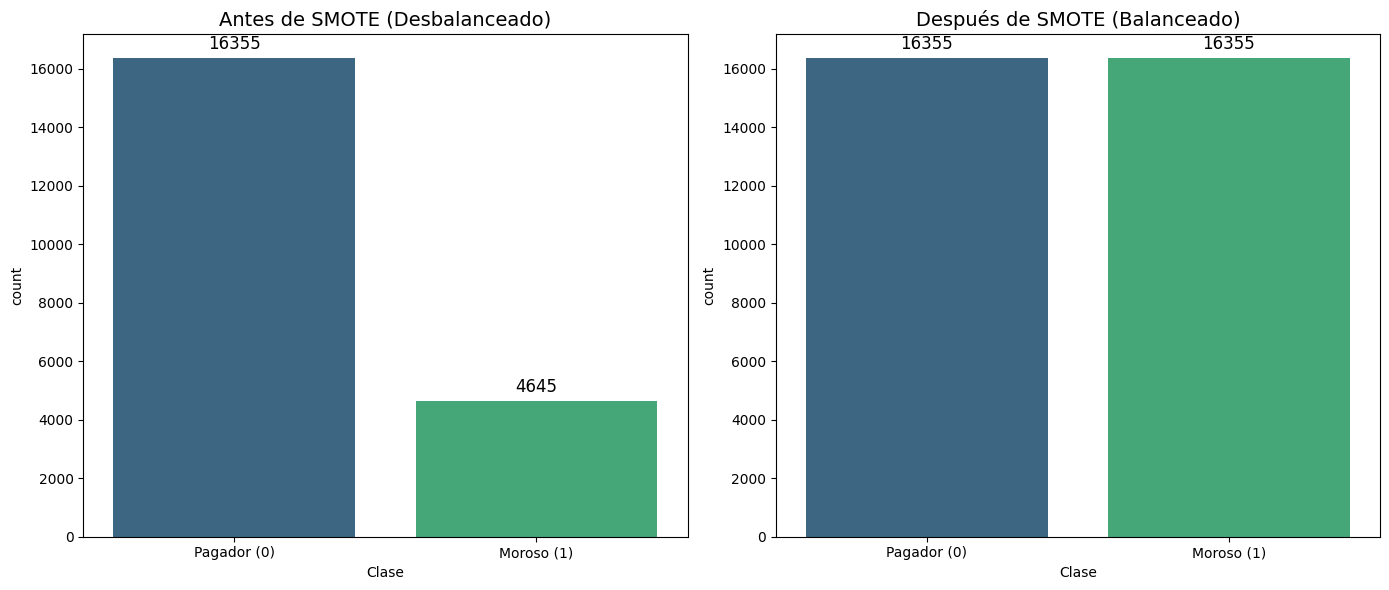

<Figure size 640x480 with 0 Axes>

In [69]:
df_antes = pd.DataFrame({'Clase': y_train})
df_despues = pd.DataFrame({'Clase': y_train_res})

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df_antes, x='Clase', ax=ax[0], palette='viridis')
ax[0].set_title('Antes de SMOTE (Desbalanceado)', fontsize=14)
ax[0].set_xticklabels(['Pagador (0)', 'Moroso (1)'])

sns.countplot(data=df_despues, x='Clase', ax=ax[1], palette='viridis')
ax[1].set_title('Después de SMOTE (Balanceado)', fontsize=14)
ax[1].set_xticklabels(['Pagador (0)', 'Moroso (1)'])

for i in range(2):
    for p in ax[i].patches:
        ax[i].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

plt.savefig('../assets/smote_comparison.jpg', dpi=300, bbox_inches='tight')

## Logistic Regresion

In [72]:
model = LogisticRegression(max_iter=100, C=1.0, random_state=42, n_jobs=-1)
model.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [73]:
y_pred_lr = model.predict(X_test_scaled)
reporte = classification_report(y_test, y_pred_lr, target_names=['Pagador (0)', 'Moroso (1)'])

print("Reporte de Clasificación - Random Forest")
print(reporte)

Reporte de Clasificación - Random Forest
              precision    recall  f1-score   support

 Pagador (0)       0.87      0.68      0.76      7009
  Moroso (1)       0.36      0.64      0.46      1991

    accuracy                           0.67      9000
   macro avg       0.62      0.66      0.61      9000
weighted avg       0.76      0.67      0.70      9000



In [74]:
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_lr))

Matriz de Confusión:
[[4771 2238]
 [ 716 1275]]


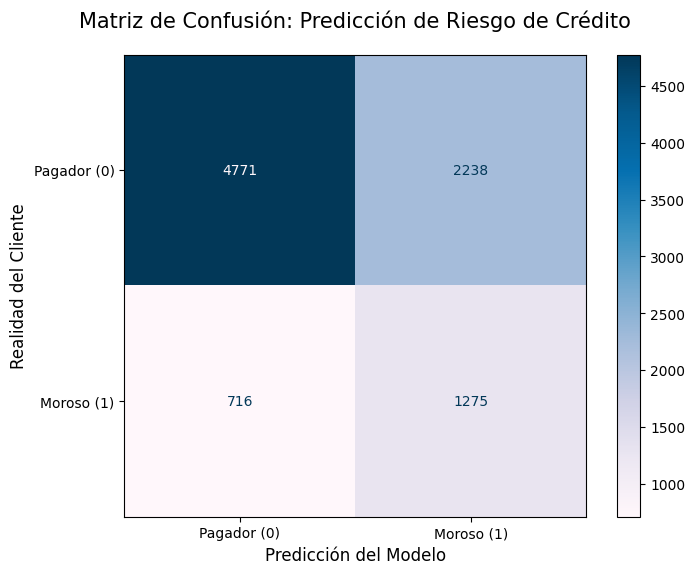

In [75]:
confma = confusion_matrix(y_test, y_pred_lr)
clases = ['Pagador (0)', 'Moroso (1)']
fig, ax = plt.subplots(figsize=(8, 6))
visual_confmatrix = ConfusionMatrixDisplay(confusion_matrix=confma, display_labels=clases)
visual_confmatrix.plot(
    cmap='PuBu',       
    ax=ax, 
    values_format='d' 
)
plt.title('Matriz de Confusión: Predicción de Riesgo de Crédito', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad del Cliente', fontsize=12)

plt.show()

In [76]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
rocauc = roc_auc_score(y_test, y_pred_lr)

In [77]:
tn = confma[0][0]
fp = confma[0][1]
specificity = tn/(tn + fp)
specificity

np.float64(0.6806962476815522)

In [78]:
model_scores = {
  'model': 'LogisticRegression',
  'accuracy': accuracy,
  'precision': precision,
  'recall': recall,
  'f1_score': f1,
  'roc_auc_score': rocauc,
  'specificity' : specificity
}
model_scores

{'model': 'LogisticRegression',
 'accuracy': 0.6717777777777778,
 'precision': 0.3629376601195559,
 'recall': 0.640381717729784,
 'f1_score': 0.4632994186046512,
 'roc_auc_score': 0.6605389827056682,
 'specificity': np.float64(0.6806962476815522)}

El modelo de Regresión Logística muestra un desempeño equilibrado con un AUC-ROC de 0.658. Gracias a la implementación de SMOTE, se ha logrado un Recall de 61.5%, priorizando la identificación de clientes en riesgo de impago. Aunque la precisión es moderada (36.8%), este comportamiento es aceptable en un entorno de gestión de riesgos donde el costo de un falso negativo (un moroso no detectado) es significativamente superior al costo de un falso positivo (un cliente solvente rechazado

In [79]:
def save_scores(model_scores: dict):
  status = []
  try:
    scores = pd.read_csv('scores.csv', sep=';')
    status.append('El archivo existe')
    exist = model_scores['model'] in scores['model'].values
    if (exist):
      status.append('El modelo existe')
      criteria = scores['model'] == model_scores['model']
      index = scores[criteria].index[0]
      scores.iloc[index] = model_scores
      status.append('Se reemplazaron los valores del modelo')
    else:
      status.append('El modelo no existe')
      df_model_scores = pd.DataFrame(model_scores, index=[0])
      scores = pd.concat([scores, df_model_scores], ignore_index=True)
      status.append('Se añadió modelo nuevo y sus valores')
  except:
    status.append('El archivo no existe')
    scores = pd.DataFrame(model_scores, index=[0])

  status.append('Se sobrescrive el archivo scores.csv con valores nuevos')
  scores.to_csv('scores.csv', sep=';', index=False)
  return status
save_scores(model_scores)

['El archivo existe',
 'El modelo existe',
 'Se reemplazaron los valores del modelo',
 'Se sobrescrive el archivo scores.csv con valores nuevos']

# Random Forest

In [100]:
model2 = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, max_features='sqrt', random_state=42, n_jobs=-1)
model2.fit(X_train_res, y_train_res)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [101]:
y_pred_rf = model2.predict(X_test_scaled)
y_pred_rf

array([0, 1, 0, ..., 0, 1, 0], shape=(9000,))

In [102]:
# Verificamos los pesos de cada atributo
model2.feature_importances_

array([0.06108317, 0.00361504, 0.02532659, 0.00313871, 0.01698499,
       0.2306117 , 0.12296977, 0.06776211, 0.04521462, 0.04062722,
       0.03950959, 0.02707238, 0.02041076, 0.01860021, 0.01650199,
       0.01550166, 0.01539658, 0.034148  , 0.0314171 , 0.0263344 ,
       0.017778  , 0.01914017, 0.02236419, 0.00794031, 0.07055074])

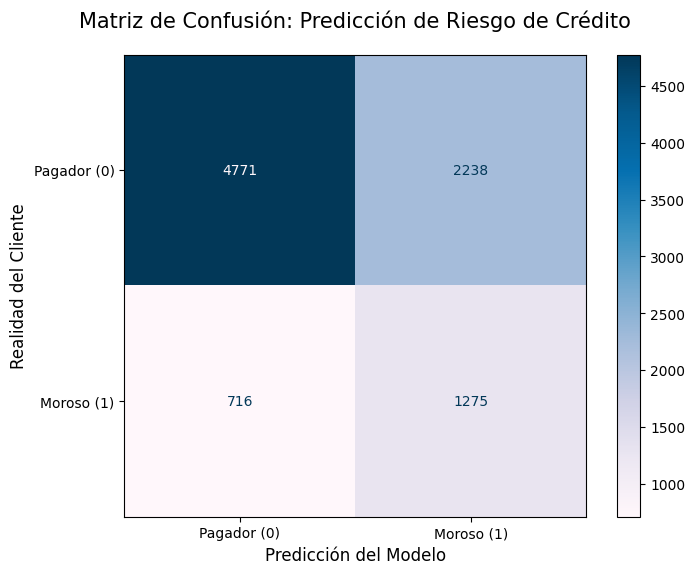

In [103]:
confma = confusion_matrix(y_test, y_pred_lr)
clases = ['Pagador (0)', 'Moroso (1)']
fig, ax = plt.subplots(figsize=(8, 6))
visual_confmatrix = ConfusionMatrixDisplay(confusion_matrix=confma, display_labels=clases)
visual_confmatrix.plot(
    cmap='PuBu',       
    ax=ax, 
    values_format='d' 
)
plt.title('Matriz de Confusión: Predicción de Riesgo de Crédito', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad del Cliente', fontsize=12)

plt.show()

In [104]:
reporte = classification_report(y_test, y_pred_rf, target_names=['Pagador (0)', 'Moroso (1)'])

print("Reporte de Clasificación - Random Forest")
print(reporte)

Reporte de Clasificación - Random Forest
              precision    recall  f1-score   support

 Pagador (0)       0.86      0.86      0.86      7009
  Moroso (1)       0.52      0.53      0.52      1991

    accuracy                           0.79      9000
   macro avg       0.69      0.69      0.69      9000
weighted avg       0.79      0.79      0.79      9000



In [105]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
rocauc = roc_auc_score(y_test, y_pred_rf)

In [106]:
tn = confma[0][0]
fp = confma[0][1]
specificity = tn/(tn + fp)
specificity

np.float64(0.6806962476815522)

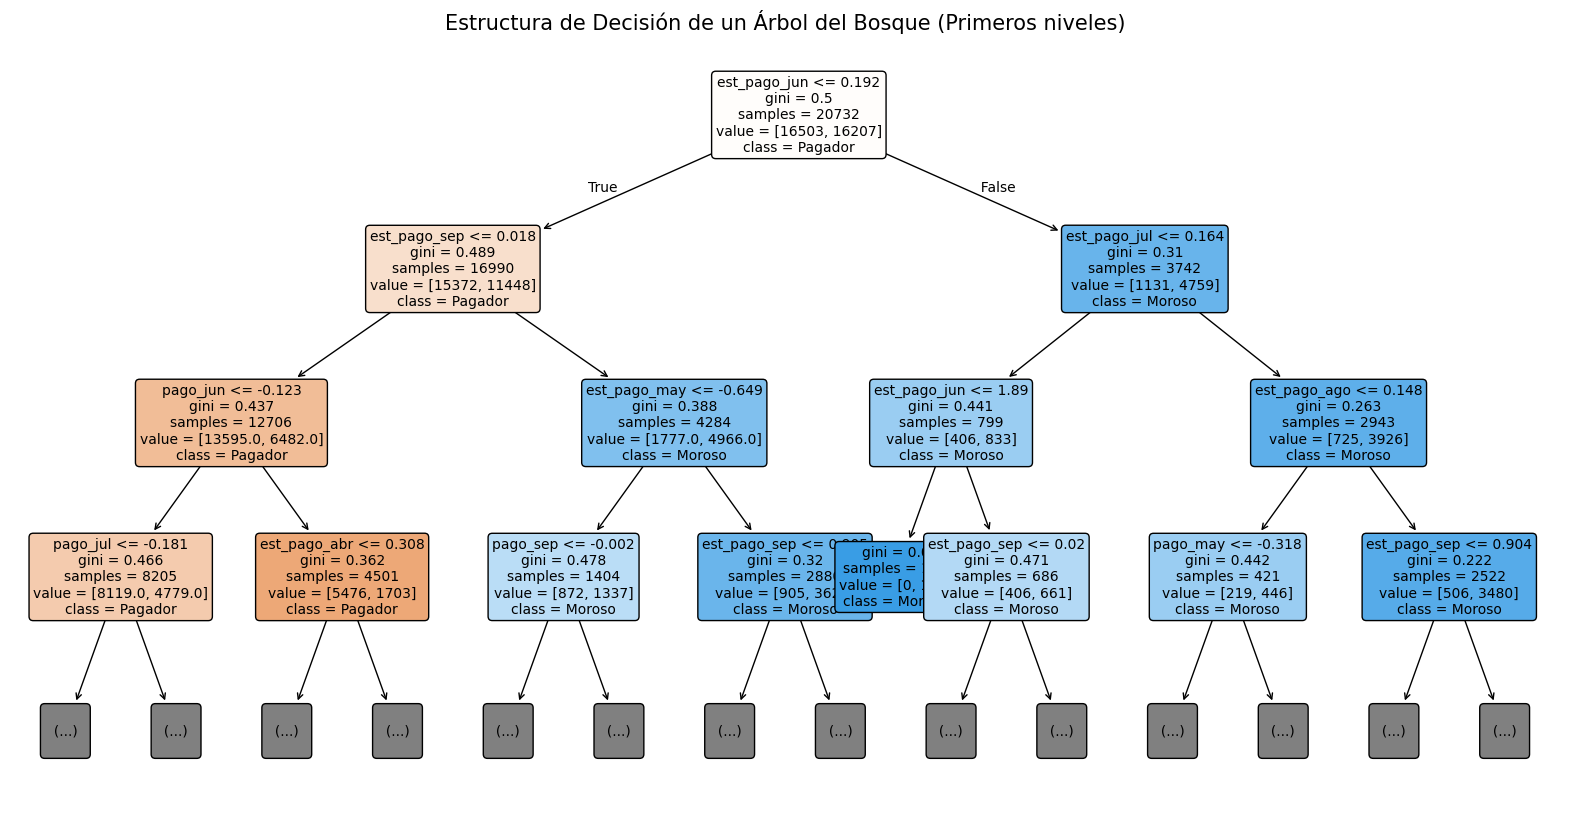

In [107]:
# Samuel
arbol_individual = model2.estimators_[0]

# 2. Configuramos el gráfico
plt.figure(figsize=(20, 10))

plot_tree(
    arbol_individual,
    max_depth=3,               
    feature_names=X_train.columns, 
    class_names=['Pagador', 'Moroso'],
    filled=True,               
    rounded=True,            
    fontsize=10
)

plt.title("Estructura de Decisión de un Árbol del Bosque (Primeros niveles)", fontsize=15)
plt.show()

Con esta imagen se ilustra visualmente el concepto de la "toma de decisiones" en un algoritmo de clasificacion random forest. No confiando en un solo "experto", sino en todo un comité por así decirlo. El nodo raiz contiene a todos los clientes con sus deudas, edades y límites de crédito. Esto hace que cada árbol sea "especialista" en algo distinto y evita que todos comentan el mismo error. Los árboles de decisión que van desde (1,2,...N)  crece de forma independiente y llega a su propio conclusión. El Arbol 1 va tomando sus propias decisiones "Este cliente es Clase B (Moroso)", el Árbol 2 analiza su parte, hasta que el árbol N (el último discrepa) y dice: "Para mí es clase A (Pagador). Una vez todos los arboles han votado, el sistema los ignora. El resultado y_pred es el ganador de esa votacion

In [108]:
model_scores2 = {
  'model': 'RandomForestClassifier',
  'accuracy': accuracy,
  'precision': precision,
  'recall': recall,
  'f1_score': f1,
  'roc_auc_score': rocauc,
  'specificity' : specificity
}
model_scores2

{'model': 'RandomForestClassifier',
 'accuracy': 0.7872222222222223,
 'precision': 0.518830525272547,
 'recall': 0.5258663987945756,
 'f1_score': 0.5223247692691444,
 'roc_auc_score': 0.6936651155051492,
 'specificity': np.float64(0.6806962476815522)}

In [52]:
save_scores(model_scores2)

['El archivo existe',
 'El modelo existe',
 'Se reemplazaron los valores del modelo',
 'Se sobrescrive el archivo scores.csv con valores nuevos']

# Fine-Tunning del Random Forest

In [110]:
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)

parametros = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 20, 30],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'n_estimators': [50, 100, 150],
}

rf_randomizedSearchCV = RandomizedSearchCV(
    model2,
    parametros,
    n_iter=162,
    cv=kfolds,
    scoring='precision', 
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_randomized_fit = rf_randomizedSearchCV.fit(X_train_res, y_train_res)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV] END bootstrap=True, criterion=gini, max_depth=10, max_features=sqrt, n_estimators=50; total time=   4.0s
[CV] END bootstrap=True, criterion=gini, max_depth=10, max_features=log2, n_estimators=150; total time=   7.3s
[CV] END bootstrap=True, criterion=gini, max_depth=20, max_features=sqrt, n_estimators=50; total time=   6.6s
[CV] END bootstrap=True, criterion=gini, max_depth=20, max_features=sqrt, n_estimators=100; total time=  10.6s
[CV] END bootstrap=True, criterion=gini, max_depth=20, max_features=log2, n_estimators=50; total time=   5.1s
[CV] END bootstrap=True, criterion=gini, max_depth=20, max_features=log2, n_estimators=150; total time=  12.2s
[CV] END bootstrap=True, criterion=gini, max_depth=30, max_features=sqrt, n_estimators=50; total time=   6.6s
[CV] END bootstrap=True, criterion=gini, max_depth=30, max_features=sqrt, n_estimators=100; total time=  10.6s
[CV] END bootstrap=True, criterion=gini, max_depth=30

In [125]:
rf_randomized_fit.best_score_

np.float64(0.8988303816117353)

In [126]:
rf_randomized_fit.best_params_

{'n_estimators': 150,
 'max_features': None,
 'max_depth': 30,
 'criterion': 'entropy',
 'bootstrap': True}

## Entreno el modelo con los hiperámetros optimizados

In [127]:
rf_optimized = RandomForestClassifier(
  n_estimators= 150, 
  max_features= None, 
  max_depth= 30,
  criterion= 'entropy',
  bootstrap= True
)

rf_optimized.fit(X_train_res, y_train_res)
predictions_optimized = rf_optimized.predict(X_test)


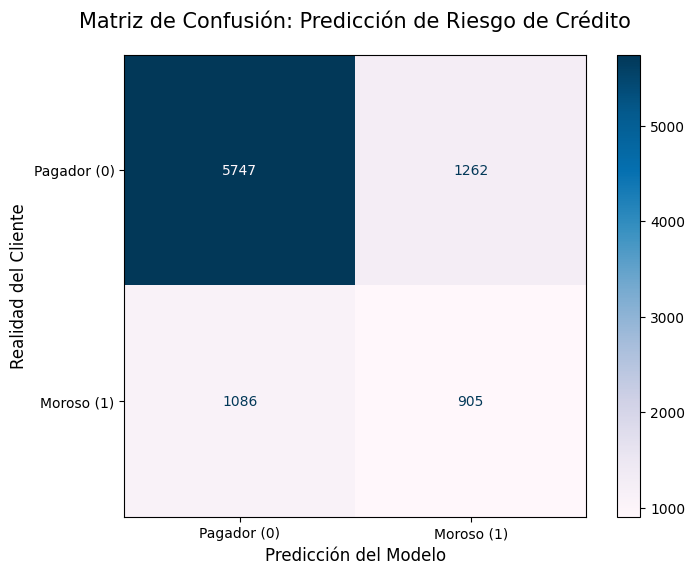

In [129]:
confma = confusion_matrix(y_test, y_pred_optimized)
clases = ['Pagador (0)', 'Moroso (1)']
fig, ax = plt.subplots(figsize=(8, 6))
visual_confmatrix = ConfusionMatrixDisplay(confusion_matrix=confma, display_labels=clases)
visual_confmatrix.plot(
    cmap='PuBu',       
    ax=ax, 
    values_format='d' 
)
plt.title('Matriz de Confusión: Predicción de Riesgo de Crédito', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad del Cliente', fontsize=12)

plt.show()

In [130]:
accuracy_optimized = accuracy_score(y_test, predictions_optimized)
precision_optimized = precision_score(y_test, predictions_optimized)
recall_optimized = recall_score(y_test, predictions_optimized)
f1_optimized = f1_score(y_test, predictions_optimized)
rocauc_optimized = roc_auc_score(y_test, predictions_optimized)
tn, fp, fn, tp = confmatrix_optimized.ravel()
specificity_optimized = tn/(tn + fp)

model_scores_optimized = {
  'model': 'RandomForestClassifierOptimized',
  'accuracy': accuracy_optimized,
  'precision': precision_optimized,
  'recall': recall_optimized,
  'f1_score': f1_optimized,
  'roc_auc_score': rocauc_optimized,
  'specificity' : specificity_optimized
}
model_scores_optimized

{'model': 'RandomForestClassifierOptimized',
 'accuracy': 0.7391111111111112,
 'precision': 0.41762805722196583,
 'recall': 0.45454545454545453,
 'f1_score': 0.4353054353054353,
 'roc_auc_score': 0.6372456192687324,
 'specificity': np.float64(0.8708802967613068)}

In [131]:
reporte = classification_report(y_test, predictions_optimized, target_names=['No Impago (0)', 'Impago (1)'])

print("Reporte de Clasificación - Random Forest Optimizado")
print(reporte)

Reporte de Clasificación - Random Forest Optimizado
               precision    recall  f1-score   support

No Impago (0)       0.84      0.82      0.83      7009
   Impago (1)       0.42      0.45      0.44      1991

     accuracy                           0.74      9000
    macro avg       0.63      0.64      0.63      9000
 weighted avg       0.75      0.74      0.74      9000



In [132]:
save_scores(model_scores_optimized)

['El archivo existe',
 'El modelo existe',
 'Se reemplazaron los valores del modelo',
 'Se sobrescrive el archivo scores.csv con valores nuevos']

## Gradient Boosting

In [238]:
gb_model = GradientBoostingClassifier(random_state=42)

parametros_gb = {
    'n_estimators': [100, 200],         
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [3, 5, 8],             
    'subsample': [0.8, 1.0],      
    'max_features': ['sqrt', 'log2']
}

gb_random_search = RandomizedSearchCV(
    gb_model,
    parametros_gb,
    n_iter=20,          
    cv=5,     
    scoring='accuracy', 
    n_jobs=-1,
    random_state=42
)

gb_random_search.fit(X_train_res, y_train_res)

best_gb = gb_random_search.best_estimator_
y_pred_gb = best_gb.predict(X_test_scaled)
y_prob = best_gb.predict_proba(X_test)[:, 1]

print("Mejores parámetros para GB:", gb_random_search.best_params_)

Mejores parámetros para GB: {'subsample': 1.0, 'n_estimators': 200, 'max_features': 'log2', 'max_depth': 8, 'learning_rate': 0.05}


In [240]:
print("Tasa de acierto en las predicciones", y_pred_gb)
print("La probabilidad de acierto:", y_prob)

Tasa de acierto en las predicciones [0 1 0 ... 0 1 0]
La probabilidad de acierto: [0.94870664 0.94284884 0.98390229 ... 0.84387073 0.74498524 0.93678667]


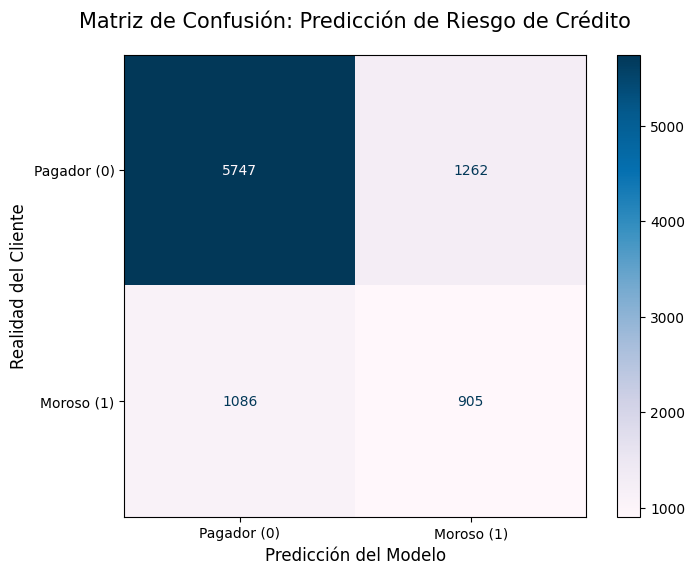

In [241]:
confma = confusion_matrix(y_test, y_pred_optimized)
clases = ['Pagador (0)', 'Moroso (1)']
fig, ax = plt.subplots(figsize=(8, 6))
visual_confmatrix = ConfusionMatrixDisplay(confusion_matrix=confma, display_labels=clases)
visual_confmatrix.plot(
    cmap='PuBu',       
    ax=ax, 
    values_format='d' 
)
plt.title('Matriz de Confusión: Predicción de Riesgo de Crédito', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad del Cliente', fontsize=12)

plt.show()

In [161]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
rocauc_gb = roc_auc_score(y_test, y_pred_gb)
tn, fp, fn, tp = confmatrix_optimized.ravel()
specificity_gb = tn/(tn + fp)

model_scores_gb = {
  'model': 'RandomForestClassifierOptimized',
  'accuracy': accuracy_gb,
  'precision': precision_gb,
  'recall': recall_gb,
  'f1_score': f1_gb,
  'roc_auc_score': rocauc_gb,
  'specificity' : specificity_gb
}
model_scores_gb

{'model': 'RandomForestClassifierOptimized',
 'accuracy': 0.8013333333333333,
 'precision': 0.5682582380632145,
 'recall': 0.4244098442993471,
 'f1_score': 0.48591144335825187,
 'roc_auc_score': 0.6664066627688774,
 'specificity': np.float64(0.8708802967613068)}

In [162]:
print("Reporte de Clasificación Final: Gradient Boosting")
print(classification_report(y_test, y_pred_gb, target_names=['No Impago (0)', 'Impago (1)']))

Reporte de Clasificación Final: Gradient Boosting
               precision    recall  f1-score   support

No Impago (0)       0.85      0.91      0.88      7009
   Impago (1)       0.57      0.42      0.49      1991

     accuracy                           0.80      9000
    macro avg       0.71      0.67      0.68      9000
 weighted avg       0.79      0.80      0.79      9000



In [163]:
save_scores(model_scores_gb)

['El archivo existe',
 'El modelo existe',
 'Se reemplazaron los valores del modelo',
 'Se sobrescrive el archivo scores.csv con valores nuevos']

# KNN

In [171]:
knn_model = KNeighborsClassifier()

knn_hiperparams = {
  'n_neighbors': [4, 6, 8, 10, 12, 14],
  'weights': ['uniform', 'distance'],
  'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
  'leaf_size': [10, 20, 30, 40, 50, 60, 70],
  'p': [1, 2]
}

knn_randomizedSearchCV = RandomizedSearchCV(
  knn_model,
  knn_hiperparams,
  n_iter=10,
  cv=kfolds,
  scoring='accuracy',
  n_jobs=-1
)

knn_randomized_fit = knn_randomizedSearchCV.fit(X_train_res, y_train_res)

In [188]:
best_knn = knn_randomized_fit.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
print("Mejores parámetros para Knn:", knn_randomized_fit.best_params_)

Mejores parámetros para Knn: {'weights': 'distance', 'p': 1, 'n_neighbors': 10, 'leaf_size': 70, 'algorithm': 'brute'}


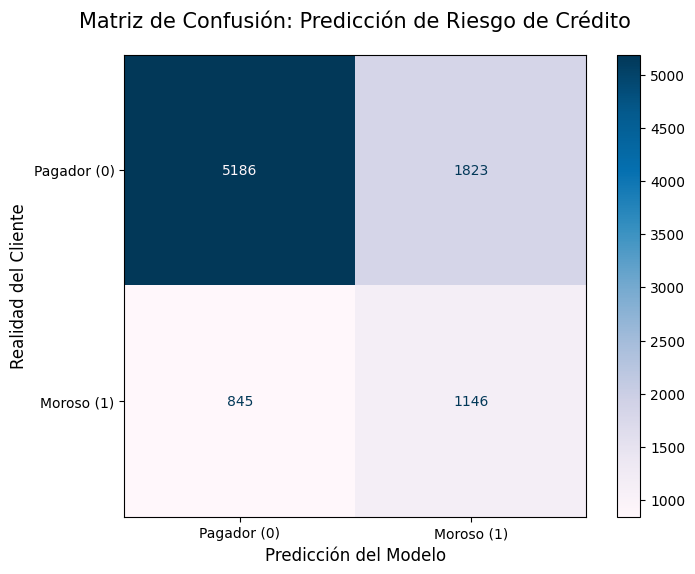

In [177]:
confma = confusion_matrix(y_test, y_pred_knn)
clases = ['Pagador (0)', 'Moroso (1)']
fig, ax = plt.subplots(figsize=(8, 6))
visual_confmatrix = ConfusionMatrixDisplay(confusion_matrix=confma, display_labels=clases)
visual_confmatrix.plot(
    cmap='PuBu',       
    ax=ax, 
    values_format='d' 
)
plt.title('Matriz de Confusión: Predicción de Riesgo de Crédito', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad del Cliente', fontsize=12)

plt.show()

In [178]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
rocauc_knn = roc_auc_score(y_test, y_pred_knn)
tn, fp, fn, tp = confma.ravel()
specificity_knn = tn/(tn + fp)

model_scores_knn = {
  'model': 'KNeighborsClassifier',
  'accuracy': accuracy_knn,
  'precision': precision_knn,
  'recall': recall_knn,
  'f1_score': f1_knn,
  'roc_auc_score': rocauc_knn,
  'specificity' : specificity_knn
}
model_scores_knn

{'model': 'KNeighborsClassifier',
 'accuracy': 0.7035555555555556,
 'precision': 0.38598854833277196,
 'recall': 0.575590155700653,
 'f1_score': 0.4620967741935484,
 'roc_auc_score': 0.6577479955275986,
 'specificity': np.float64(0.7399058353545441)}

In [179]:
print("Reporte de Clasificación Final: KNN")
print(classification_report(y_test, y_pred_knn, target_names=['No Impago (0)', 'Impago (1)']))

Reporte de Clasificación Final: KNN
               precision    recall  f1-score   support

No Impago (0)       0.86      0.74      0.80      7009
   Impago (1)       0.39      0.58      0.46      1991

     accuracy                           0.70      9000
    macro avg       0.62      0.66      0.63      9000
 weighted avg       0.76      0.70      0.72      9000



In [180]:
save_scores(model_scores_knn)

['El archivo existe',
 'El modelo existe',
 'Se reemplazaron los valores del modelo',
 'Se sobrescrive el archivo scores.csv con valores nuevos']

## Evaluar mejor modelo

In [181]:
scores = pd.read_csv('scores.csv', sep=';')
scores

,model,accuracy,precision,recall,f1_score,roc_auc_score,specificity
0,LogisticRegression,0.671778,0.362938,0.640382,0.463299,0.660539,0.680696
1,RandomForestClassifier,0.673000,0.362375,0.629992,0.460099,0.657603,0.685213
2,RandomForestClassifierOptimized,0.801333,0.568258,0.424410,0.485911,0.666407,0.870880
3,GradientBoostingClassifier,0.797333,0.549865,0.461191,0.501639,0.676990,0.892788
4,KNeighborsClassifier,0.703556,0.385989,0.575590,0.462097,0.657748,0.739906


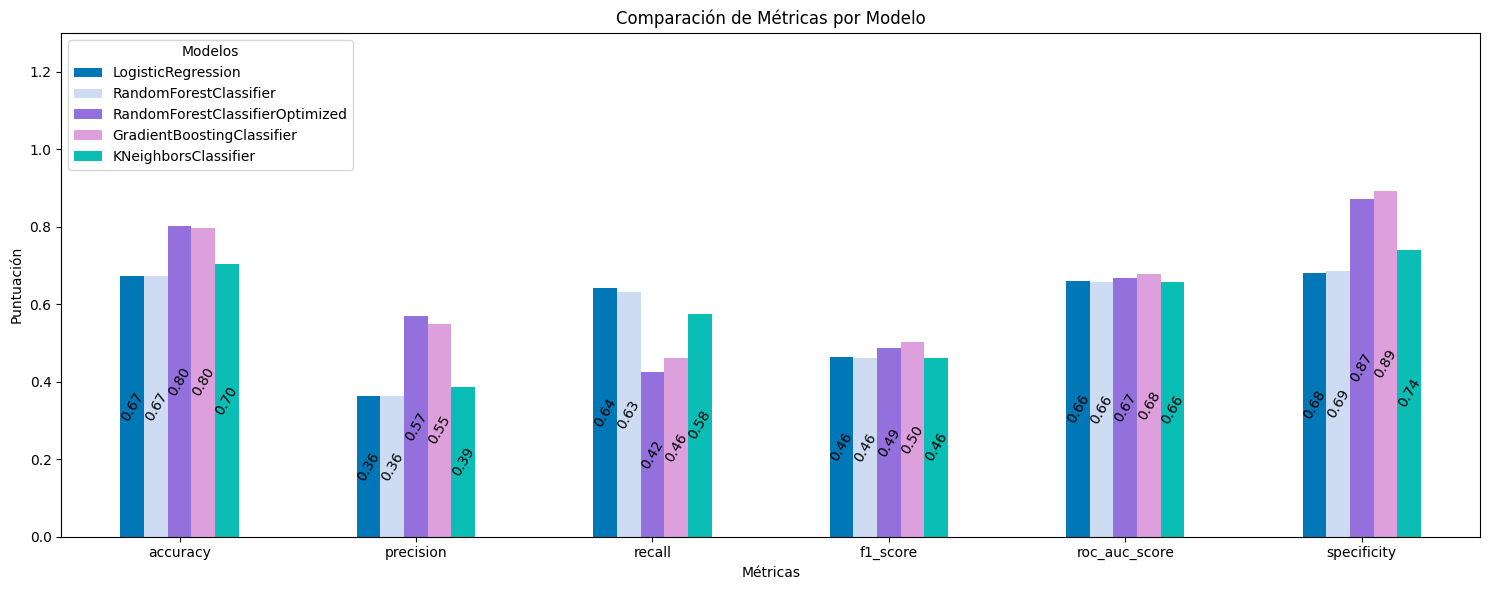

In [183]:
colors = ['#0077b6', '#CDDBF3','#9370DB', '#DDA0DD', '#0abeb5', 'red']
results_df = scores.set_index('model')
results_df = results_df.T
plot = results_df.plot(kind='bar', figsize=(15, 6), colormap='viridis', rot=0, color=colors)
for metric in plot.containers:
  labels = []
  for bar in metric:
    labels.append(f'{bar.get_height():.2f}')
  plot.bar_label(metric, labels=labels, label_type='center', rotation=60)
plt.title('Comparación de Métricas por Modelo')
plt.xlabel('Métricas')
plt.ylabel('Puntuación')
plt.ylim(0,1.3)
plt.legend(title='Modelos', loc='upper left')
plt.tight_layout()
plt.show()

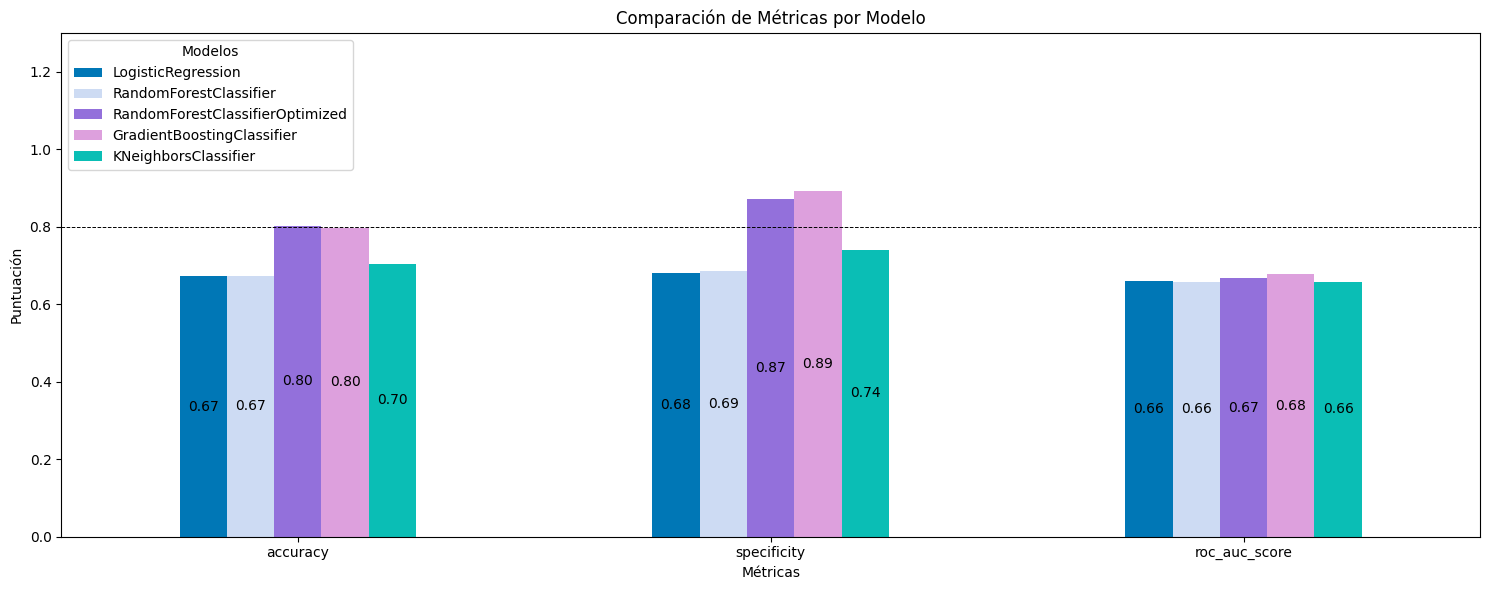

In [184]:
results_df = results_df.loc[['accuracy', 'specificity', 'roc_auc_score']]
plot = results_df.plot(kind='bar', figsize=(15, 6), colormap='viridis', rot=0, color=colors)
for metric in plot.containers:
  labels = []
  for bar in metric:
    labels.append(f'{bar.get_height():.2f}')
  plot.bar_label(metric, labels=labels, label_type='center', rotation=0)
plt.title('Comparación de Métricas por Modelo')
plt.xlabel('Métricas')
plt.ylabel('Puntuación')
plt.ylim(0,1.3)
plt.axhline(y=0.8, color='black', linestyle='--', linewidth=0.7)
plt.legend(title='Modelos', loc='upper left')
plt.tight_layout()

plt.show()

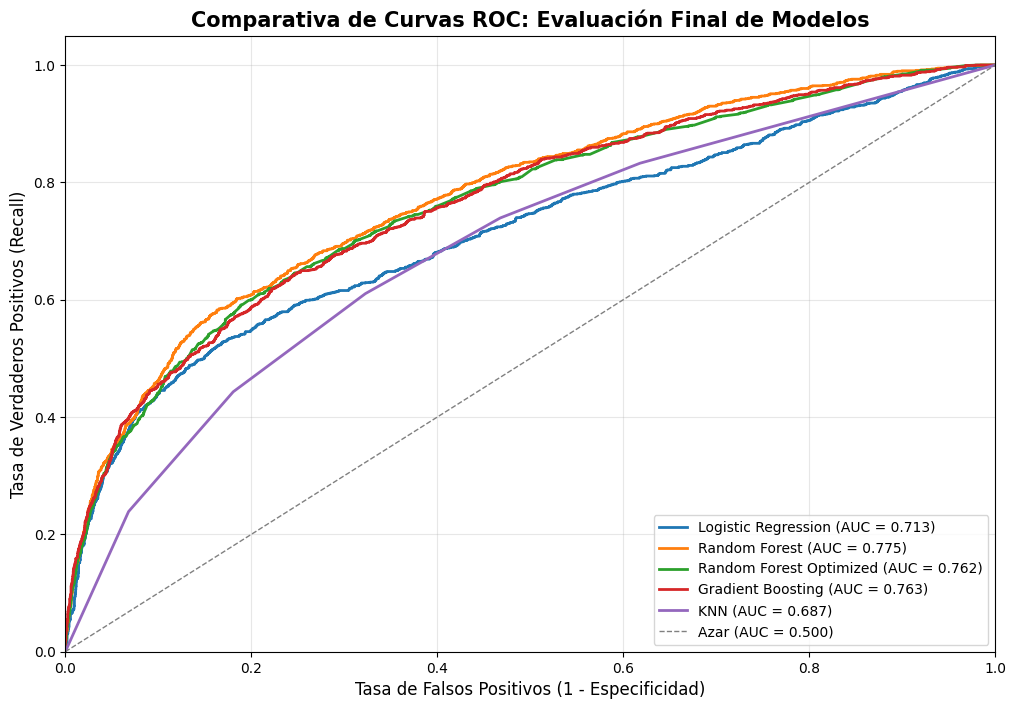

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_res, y_train_res)

modelos_finales = {
    'Logistic Regression': model,
    'Random Forest': model2,
    'Random Forest Optimized': rf_optimized, 
    'Gradient Boosting': best_gb,       
    'KNN': knn_model                    
}

plt.figure(figsize=(12, 8))

for nombre, modelo in modelos_finales.items():
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Azar (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
plt.title('Comparativa de Curvas ROC: Evaluación Final de Modelos', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.show()

# Explicabilidad de Modelos de Clasificación con SHAP

In [76]:
explainer = shap.TreeExplainer(best_gb)
X_test_subset = X_test_scaled[:100]
shap_values = explainer(X_test_subset)

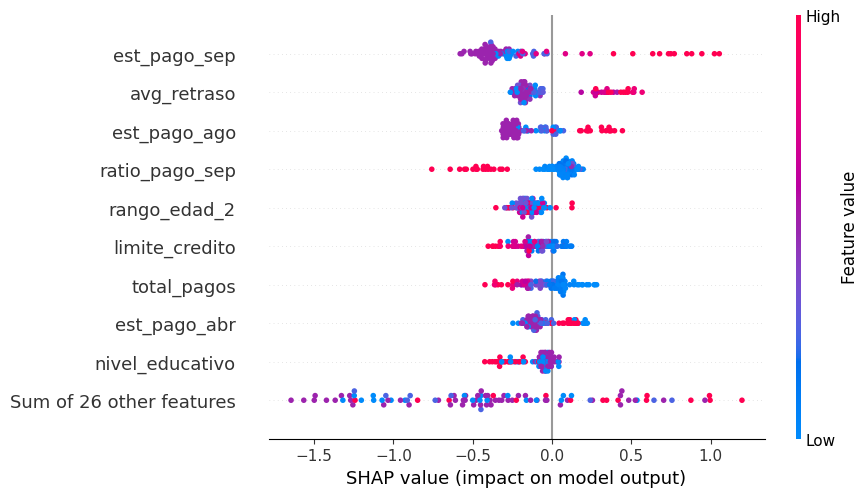

In [80]:
shap_values.feature_names = list(X_train)
shap.plots.beeswarm(shap_values)

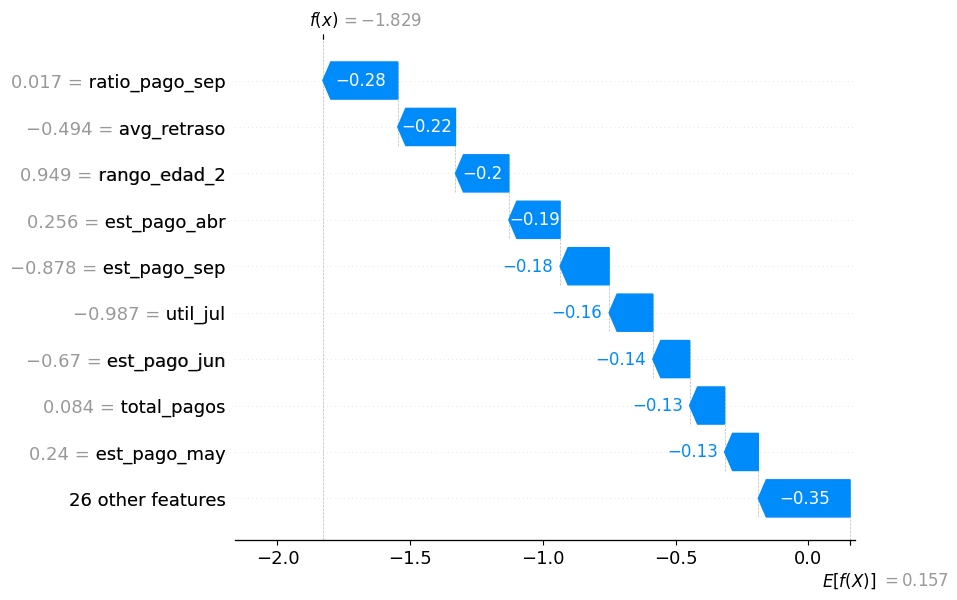

In [81]:
shap.plots.waterfall(shap_values[0])

# Predicción del riesgo

In [251]:
if 'gb_random_search' in locals():
    gb_model = gb_random_search.best_estimator_
elif 'best_gb' in locals():
    gb_model = best_gb
    print("Modelo extraído de best_gb")
else:
    gb_model = joblib.load('mejor_modelo_gradient_boosting.pkl')
    print("Modelo cargado desde archivo")
try:
    check_is_fitted(gb_model)
    print("Verificación exitosa: El modelo está listo para predecir.")
    joblib.dump(gb_model, 'mejor_modelo_gradient_boosting.pkl')
except NotFittedError:
    print("ERROR: El modelo sigue sin estar entrenado. Ejecuta la celda de 'gb_random_search.fit' antes.")


Verificación exitosa: El modelo está listo para predecir.


In [254]:
escalador = joblib.load('escalador_uax.pkl')
gb = joblib.load('mejor_modelo_gradient_boosting.pkl')
joblib.dump(mejor_modelo_entrenado, 'mejor_modelo_gradient_boosting.pkl')

['mejor_modelo_gradient_boosting.pkl']

In [259]:
def gauge(labels=['LOW','MEDIUM','HIGH','V. HIGH','EXTREME'], 
          colors='RdYlGn_r', arrow=1, title=''):
    n_colors = len(labels)
    if isinstance(colors, str):
        cmap = plt.get_cmap(colors)
        colors = cmap(np.linspace(0, 1, n_colors))
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, color in enumerate(colors):
        theta_start = np.pi - (i * np.pi / n_colors)
        theta_end = np.pi - ((i + 1) * np.pi / n_colors)
        theta = np.linspace(theta_start, theta_end, 100)
        x_inner = 1.0 * np.cos(theta)
        y_inner = 1.0 * np.sin(theta)
        x_outer = 1.5 * np.cos(theta)
        y_outer = 1.5 * np.sin(theta)
        
        ax.fill(np.concatenate([x_inner, x_outer[::-1]]),
                np.concatenate([y_inner, y_outer[::-1]]),
                color=color, alpha=0.7)
    for i, label in enumerate(labels):
        angle = np.pi - (i + 0.5) * np.pi / n_colors
        x = 1.25 * np.cos(angle)
        y = 1.25 * np.sin(angle)
        ax.text(x, y, label, horizontalalignment='center', 
                verticalalignment='center', fontsize=12, fontweight='bold')
    angle_arrow = np.pi - (arrow - 0.5) * np.pi / n_colors
    ax.annotate('', xy=(1.1 * np.cos(angle_arrow), 1.1 * np.sin(angle_arrow)),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='wedge,tail_width=0.5', color='black', lw=2))
    circle = plt.Circle((0, 0), 0.15, color='black')
    ax.add_patch(circle)
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-0.1, 1.6)
    ax.axis('off')
    plt.title(title, fontsize=16, pad=20, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
def convert(aCustomer: pd.DataFrame):
    customer = aCustomer.copy()
    features_base = [
        'limite_credito', 'genero', 'nivel_educativo', 'estado_civil', 'edad',
        'est_pago_sep', 'est_pago_ago', 'est_pago_jul', 'est_pago_jun',
        'est_pago_may', 'est_pago_abr', 'deuda_sep', 'deuda_ago', 'deuda_jul',
        'deuda_jun', 'deuda_may', 'deuda_abr', 'pago_sep', 'pago_ago',
        'pago_jul', 'pago_jun', 'pago_may', 'pago_abr'
    ]
    
    customer['rango_edad'] = pd.cut(x=customer['edad'], 
                                    bins=[18, 30, 40, 50, 60, 80], 
                                    labels=[1, 2, 3, 4, 5]).astype(int)
    customer['rango_valor_credito'] = pd.cut(x=customer['limite_credito'], 
                                             bins=[0, 50000, 100000, 200000, 500000, 1000000], 
                                             labels=[1, 2, 3, 4, 5]).astype(int)
    
    cols_para_escalar = features_base + ['rango_edad', 'rango_valor_credito']
    
    customer_filtered = customer[cols_para_escalar].fillna(0)
    customer_normalized = escalador.transform(customer_filtered)  
    return customer_normalized

def set_arrow(prob: float) -> int:   
    if (prob >= 80):
        return 5 # EXTREME
    elif (prob >= 60):
        return 4 # V. HIGH
    elif (prob >= 40):
        return 3 # HIGH
    elif (prob >= 20):
        return 2 # MEDIUM
    else:
        return 1 # LOW

def predict_and_plot(customer_df, title="RIESGO DE CRÉDITO"):
    data_norm = convert(customer_df)
    prob_impago = gb_model.predict_proba(data_norm)[0][1] * 100
    posicion = set_arrow(prob_impago)
    gauge(labels=['LOW','MEDIUM','HIGH','V. HIGH','EXTREME'], 
          colors='RdYlGn_r', 
          arrow=posicion, 
          title=f"{title}: {prob_impago:.1f}%")

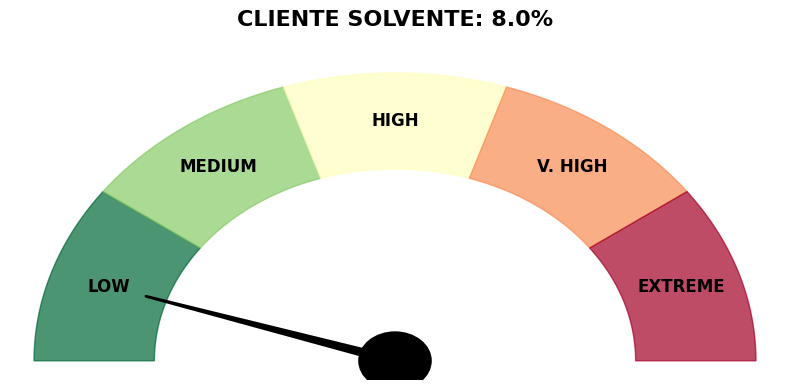

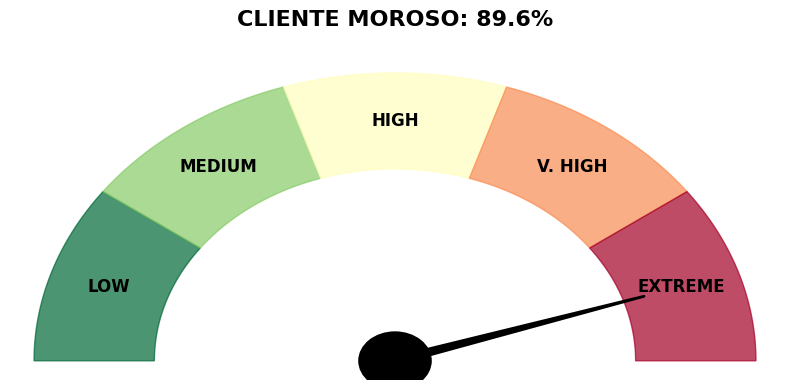

In [261]:
cols_input = [
    'limite_credito', 'genero', 'nivel_educativo', 'estado_civil', 'edad',
    'est_pago_sep', 'est_pago_ago', 'est_pago_jul', 'est_pago_jun',
    'est_pago_may', 'est_pago_abr', 'deuda_sep', 'deuda_ago', 'deuda_jul',
    'deuda_jun', 'deuda_may', 'deuda_abr', 'pago_sep', 'pago_ago',
    'pago_jul', 'pago_jun', 'pago_may', 'pago_abr'
]

cliente_top = pd.DataFrame([[150000, 2, 1, 1, 40, 0, 0, 0, 0, 0, 0, 100, 100, 100, 100, 100, 100, 5000, 5000, 5000, 5000, 5000, 5000]], columns=cols_input)
cliente_riesgo = pd.DataFrame([[10000, 1, 3, 2, 22, 2, 2, 2, 2, 2, 2, 9000, 9500, 9800, 9900, 9950, 10000, 0, 0, 0, 0, 0, 0]], columns=cols_input)

predict_and_plot(cliente_top, "CLIENTE SOLVENTE")
predict_and_plot(cliente_riesgo, "CLIENTE MOROSO")